In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=20,    # Повороты до 20 градусов
    shear_range=0.2,      # Сдвиги углов (shear)
    zoom_range=0.2,       # Зум до 20%
    horizontal_flip=True, # Горизонтальное отражение
    validation_split=0.2,  # 80% для обучения, 20% для валидации
    rescale=1./255,
    width_shift_range=0.2, # Горизонтальные сдвиги
    height_shift_range=0.2, # Вертикальные сдвиги
    fill_mode='nearest'   # Заполнение пикселей при сдвигах
)

# Генератор для тренировочной выборки
train_generator = datagen.flow_from_directory(
    'C:/Users/Andrey/Desktop/flowers',        # путь к общей папке
    target_size=(128, 128),   # Преобразуем изображения к размеру 128x128
    batch_size=32,            # Размер пакета
    class_mode='categorical', # Классификация на несколько классов
    subset='training'         # Используем 80% данных
)

# Генератор для валидационной выборки
val_generator = datagen.flow_from_directory(
    'C:/Users/Andrey/Desktop/flowers',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'       # Используем 20% данных
)

Found 3457 images belonging to 5 classes.
Found 860 images belonging to 5 classes.


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model_cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')  # 5 классов
])
model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

C:\anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [47]:
history = model_cnn.fit(train_generator, epochs=20, validation_data=val_generator)

Epoch 1/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 38s 335ms/step - accuracy: 0.3471 - loss: 1.4556 - val_accuracy: 0.5570 - val_loss: 1.1457
Epoch 2/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 41s 379ms/step - accuracy: 0.5227 - loss: 1.1453 - val_accuracy: 0.6174 - val_loss: 1.0124
Epoch 3/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 39s 357ms/step - accuracy: 0.6025 - loss: 1.0059 - val_accuracy: 0.6395 - val_loss: 0.9451
Epoch 4/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 41s 373ms/step - accuracy: 0.6215 - loss: 0.9489 - val_accuracy: 0.6256 - val_loss: 0.9418
Epoch 5/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 41s 372ms/step - accuracy: 0.5988 - loss: 1.0259 - val_accuracy: 0.6744 - val_loss: 0.8320
Epoch 6/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 37s 341ms/step - accuracy: 0.6500 - loss: 0.9072 - val_accuracy: 0.6523 - val_loss: 0.8939
Epoch 7/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 37s 336ms/step - accuracy: 0.6639 - loss: 0.8716 - val_accuracy: 0.6756 - val_loss: 0.8536
Epoch 8/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 36s 330ms/step - accuracy: 0.6543 - loss: 0

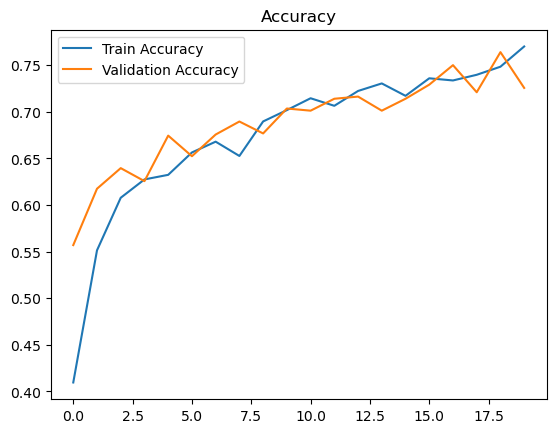

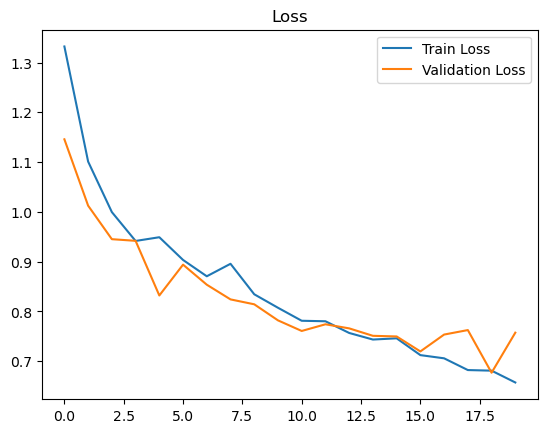

In [51]:
import matplotlib.pyplot as plt

# График точности
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

# График потерь
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.show()

In [ ]:
from tensorflow.keras.optimizers import Adam

model_fcn = Sequential([
    # Входной слой - изображение преобразуется в одномерный вектор
    Flatten(input_shape=(128, 128, 3)),  # Преобразуем изображение 128x128x3 в одномерный вектор
    # Первый полносвязный слой
    Dense(512, activation='relu'),  # 512 нейронов
    Dropout(0.2),                   # Регуляризация через dropout

    # Второй полносвязный слой
    Dense(256, activation='relu'),  # 256 нейронов
    Dropout(0.2),                   # Регуляризация через dropout

    Dense(256, activation='relu'),  
    Dropout(0.2),                   # Регуляризация через dropout
    Dense(128, activation='relu'),  
    Dropout(0.2),                   # Регуляризация через dropout
    Dense(64, activation='relu'),  
    Dense(32, activation='relu'),  
    # Выходной слой для классификации на 5 классов
    Dense(5, activation='softmax')  # 5 классов, softmax для вероятностей
])

# Компиляция модели
model_fcn.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

C:\anaconda\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [78]:
history_fcn = model_fcn.fit(train_generator, epochs=20, validation_data=val_generator)

Epoch 1/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 53s 472ms/step - accuracy: 0.2420 - loss: 3.9965 - val_accuracy: 0.3326 - val_loss: 1.5107
Epoch 2/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 60s 550ms/step - accuracy: 0.3538 - loss: 1.4402 - val_accuracy: 0.4256 - val_loss: 1.3682
Epoch 3/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 52s 473ms/step - accuracy: 0.3903 - loss: 1.3893 - val_accuracy: 0.3698 - val_loss: 1.4004
Epoch 4/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 45s 414ms/step - accuracy: 0.3995 - loss: 1.3658 - val_accuracy: 0.3919 - val_loss: 1.3947
Epoch 5/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 42s 390ms/step - accuracy: 0.3955 - loss: 1.3706 - val_accuracy: 0.3942 - val_loss: 1.3488
Epoch 6/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 46s 423ms/step - accuracy: 0.3936 - loss: 1.3372 - val_accuracy: 0.3942 - val_loss: 1.3459
Epoch 7/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 41s 376ms/step - accuracy: 0.4302 - loss: 1.2997 - val_accuracy: 0.3802 - val_loss: 1.3764
Epoch 8/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 37s 338ms/step - accuracy: 0.3947 - loss: 1

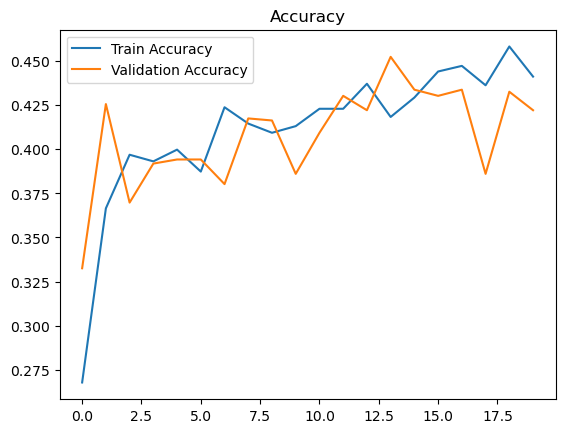

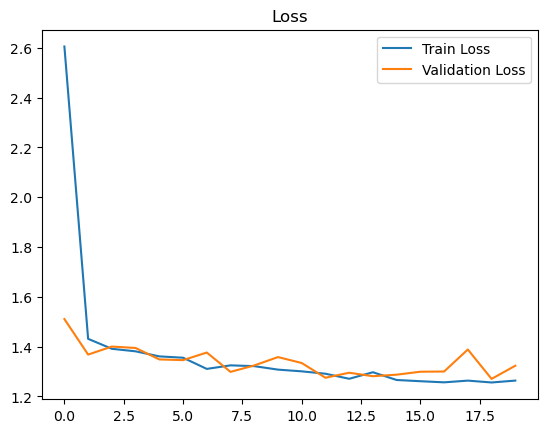

In [82]:
# График точности
plt.plot(history_fcn.history['accuracy'], label='Train Accuracy')
plt.plot(history_fcn.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

# График потерь
plt.plot(history_fcn.history['loss'], label='Train Loss')
plt.plot(history_fcn.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.show()

In [ ]:
autoencoder_datagen = ImageDataGenerator(
    rotation_range=20,    # Повороты до 20 градусов
    shear_range=0.2,      # Сдвиги углов (shear)
    zoom_range=0.2,       # Зум до 20%
    horizontal_flip=True, # Горизонтальное отражение
    validation_split=0.2,  # 80% для обучения, 20% для валидации
    rescale=1./255,
    width_shift_range=0.2, # Горизонтальные сдвиги
    height_shift_range=0.2, # Вертикальные сдвиги
    fill_mode='nearest'   # Заполнение пикселей при сдвигах
)

# Генератор для тренировочной выборки
autoencoder_train_generator = datagen.flow_from_directory(
    'C:/Users/Andrey/Desktop/flowers',        # путь к общей папке
    target_size=(128, 128),   # Преобразуем изображения к размеру 128x128
    batch_size=32,            # Размер пакета
    class_mode='input', # Классификация на несколько классов
    subset='training'         # Используем 80% данных
)

# Генератор для валидационной выборки
autoencoder_val_generator = datagen.flow_from_directory(
    'C:/Users/Andrey/Desktop/flowers',
    target_size=(128, 128),
    batch_size=32,
    class_mode='input',
    subset='validation'       # Используем 20% данных
)

Found 3457 images belonging to 5 classes.
Found 860 images belonging to 5 classes.


In [11]:
from tensorflow.keras.layers import Reshape
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Энкодер (сжимающий слой)
autoencoder_encoder = Sequential([
    Flatten(input_shape=(128, 128, 3)),  # Преобразуем изображение в одномерный вектор
    Dense(256, activation='relu')  # Сжимаем изображение до 256 признаков
])

# Декодер (восстановление)
autoencoder_decoder = Sequential([
    Dense(128 * 128 * 3, activation='sigmoid', input_shape=(256,)),  # Восстановление изображения
    Reshape((128, 128, 3))  # Возвращаем форму исходного изображения
])

# Полный автокодировщик (энкодер + декодер)
autoencoder = Sequential([autoencoder_encoder, autoencoder_decoder])

# Компиляция модели
autoencoder.compile(loss="mse", optimizer='adam')

# Обучение автокодировщика
autoencoder.fit(
    autoencoder_train_generator,  # Генератор обучающих данных
    epochs=40,
    validation_data=autoencoder_val_generator
)

C:\anaconda\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\anaconda\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - loss: 0.0741

C:\anaconda\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


109/109 ━━━━━━━━━━━━━━━━━━━━ 51s 456ms/step - loss: 0.0740 - val_loss: 0.0573
Epoch 2/40
109/109 ━━━━━━━━━━━━━━━━━━━━ 35s 316ms/step - loss: 0.0540 - val_loss: 0.0537
Epoch 3/40
109/109 ━━━━━━━━━━━━━━━━━━━━ 34s 312ms/step - loss: 0.0503 - val_loss: 0.0503
Epoch 4/40
109/109 ━━━━━━━━━━━━━━━━━━━━ 37s 341ms/step - loss: 0.0479 - val_loss: 0.0495
Epoch 5/40
109/109 ━━━━━━━━━━━━━━━━━━━━ 39s 355ms/step - loss: 0.0481 - val_loss: 0.0491
Epoch 6/40
109/109 ━━━━━━━━━━━━━━━━━━━━ 35s 318ms/step - loss: 0.0475 - val_loss: 0.0475
Epoch 7/40
109/109 ━━━━━━━━━━━━━━━━━━━━ 38s 351ms/step - loss: 0.0469 - val_loss: 0.0466
Epoch 8/40
109/109 ━━━━━━━━━━━━━━━━━━━━ 38s 347ms/step - loss: 0.0453 - val_loss: 0.0450
Epoch 9/40
109/109 ━━━━━━━━━━━━━━━━━━━━ 38s 351ms/step - loss: 0.0445 - val_loss: 0.0488
Epoch 10/40
109/109 ━━━━━━━━━━━━━━━━━━━━ 34s 315ms/step - loss: 0.0458 - val_loss: 0.0463
Epoch 11/40
109/109 ━━━━━━━━━━━━━━━━━━━━ 39s 355ms/step - loss: 0.0530 - val_loss: 0.0467
Epoch 12/40
109/109 ━━━━━━━━━━

In [13]:
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Извлечение энкодера из автокодировщика
autoencoder = autoencoder_encoder

# Замораживание весов энкодера, чтобы не переобучать уже обученные слои
autoencoder.trainable = False

# Создание классификатора
classifier = Sequential([
    autoencoder, # Используем энкодер как первый слой
    Dense(256, activation="relu"), # Добавляем полносвязный слой
    Dense(256, activation="relu"), # Добавляем полносвязный слой
    Dense(128, activation="relu"), # Добавляем полносвязный слой
    Dense(128, activation="relu"), # Добавляем полносвязный слой
    Dense(64, activation="relu"), # Добавляем полносвязный слой
    Dense(32, activation="relu"), # Добавляем полносвязный слой
    #Dropout(0.5), # Dropout для предотвращения переобучения
    Dense(5, activation="softmax") # Выходной слой для 5 классов
])

# Компиляция модели
classifier.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Обучение классификатора
history = classifier.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator
)

Epoch 1/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 35s 293ms/step - accuracy: 0.3257 - loss: 1.5222 - val_accuracy: 0.3663 - val_loss: 1.3782
Epoch 2/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 31s 284ms/step - accuracy: 0.3723 - loss: 1.3859 - val_accuracy: 0.4012 - val_loss: 1.3540
Epoch 3/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 31s 283ms/step - accuracy: 0.3884 - loss: 1.3554 - val_accuracy: 0.4198 - val_loss: 1.3196
Epoch 4/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 31s 285ms/step - accuracy: 0.4241 - loss: 1.3156 - val_accuracy: 0.4058 - val_loss: 1.3226
Epoch 5/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 24s 216ms/step - accuracy: 0.4278 - loss: 1.3116 - val_accuracy: 0.3977 - val_loss: 1.3256
Epoch 6/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 19s 170ms/step - accuracy: 0.4232 - loss: 1.2966 - val_accuracy: 0.4198 - val_loss: 1.3265
Epoch 7/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 18s 169ms/step - accuracy: 0.4265 - loss: 1.2823 - val_accuracy: 0.4209 - val_loss: 1.3039
Epoch 8/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 18s 169ms/step - accuracy: 0.4387 - loss: 1

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
# Загрузка и подготовка изображения
img_path = 'C:/Users/Andrey/Downloads/krasivyi-buket-romashek-kartinka-4.webp'  # Укажите путь к вашему изображению
img = image.load_img(img_path, target_size=(128, 128))  # Измените размер под вход модели
img_array = image.img_to_array(img)  # Преобразуйте изображение в массив
img_array = np.expand_dims(img_array, axis=0)  # Добавьте размерность для батча

# Нормализация значений пикселей
img_array /= 255.0  # Нормализация

# Прогнозирование
predictions = classifier.predict(img_array)  # Передача изображения в predict
predicted_class = np.argmax(predictions, axis=1)  # Получение индекса класса с максимальной вероятностью

# Интерпретация результатов
class_names = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']  # Замените на ваши имена классов
print(f'Предсказанный класс: {predicted_class[0]}')
print(f'Имя предсказанного класса: {class_names[predicted_class[0]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
Предсказанный класс: 0
Имя предсказанного класса: daisy


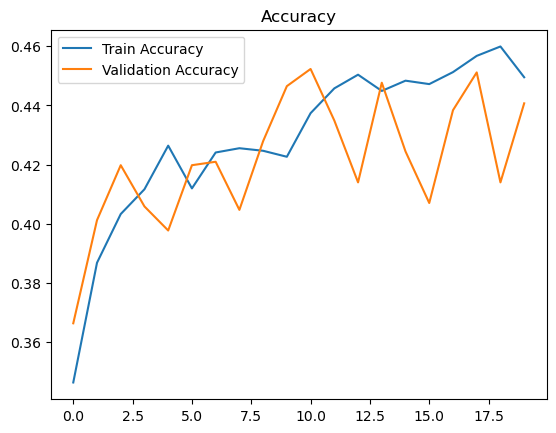

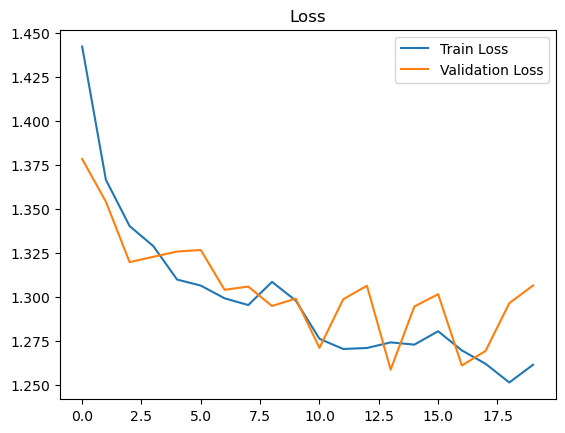

In [25]:
import matplotlib.pyplot as plt
# График точности
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

# График потерь
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.show()